# Location entropy in NYC and Tokyo Foursquare check-ins

**Question.** How concentrated or diverse are users' observed venue-visiting patterns, and how do those patterns vary by city and weekday/weekend context?

This executed report treats that as an empirical question. It separates dataset-specific validation from a reusable entropy implementation, reports only aggregates, and ends with one product proposal tied to the observed evidence.

**Executive summary.** Typical normalized venue entropy is similar in the two samples (median **0.853 NYC**, **0.860 Tokyo**), though similar normalized scores need not represent similar category mixes. Among users meeting the pre-specified 20-check-in threshold in each context, weekend entropy is typically higher (median weekend-minus-weekday **0.058 NYC**, **0.059 Tokyo**). Venue and category diversity are strongly associated, but Tokyo's median normalized category entropy is lower. These descriptive, historical, opt-in check-in patterns motivate *context-aware venue discovery*; they do not support causal or cultural claims.

## 1. Reproducible setup

**Decision and rationale.** Paths are project-relative; dependencies and Python constraints are locked by `uv.lock`. A fixed seed is used for the optional bootstrap. The raw files remain unchanged and ignored by Git.

In [1]:
from dataclasses import asdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from location_entropy import calculate_location_entropy, prepare_city_data

SEED = 20250308
rng = np.random.default_rng(SEED)
sns.set_theme(style="whitegrid", context="notebook")

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "pyproject.toml").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
DATA_DIR = PROJECT_ROOT / "dataset_tsmc2014"
FILES = {
    "NYC": DATA_DIR / "dataset_TSMC2014_NYC.txt",
    "TKY": DATA_DIR / "dataset_TSMC2014_TKY.txt",
}
assert all(path.is_file() for path in FILES.values()), "Download both expected files; see README.md"
CITY_ORDER = list(FILES)
PROJECT_ROOT

PosixPath('/Users/winnee/tao/infomina-ai-test')

## 2. Load, validate, and clean

**Question → evidence.** Are both files structurally trustworthy enough for the comparison? The source is headerless, Latin-1 TSV; UTF-8 is known to fail. The loader therefore supplies all eight names and dtypes, parses UTC explicitly, and rejects malformed rows, blanks, invalid coordinates, or invalid timestamps. The table below is computed, not copied from the specification.

**Decision.** Remove exact duplicate source rows because retaining repeated identical events would give those events extra probability mass. Keep `Home (private)` because it represents routine behavior, but never output coordinates, trajectories, or raw user IDs. Retain the supplied offset only as a validation field. Derive local time with `America/New_York` and `Asia/Tokyo`, which handles NYC daylight saving correctly.

**Alternative rejected.** Conversion to CSV/Parquet adds no analytical value here and could alter parsing; production scaling formats are discussed later. A canonical venue table is also out of scope: venue-ID entropy does not need one, and category entropy uses each event's recorded `category_id`.

In [2]:
frames = []
quality_reports = []
for city, path in FILES.items():
    frame, report = prepare_city_data(path, city)
    # Derive context before concatenating columns with different city time zones.
    frame["context"] = np.where(frame["local_time"].dt.dayofweek >= 5, "weekend", "weekday")
    frames.append(frame)
    quality_reports.append(asdict(report))

quality = pd.json_normalize(quality_reports).set_index("city")
expected = {
    "NYC": {"raw_rows": 227_428, "exact_duplicates": 250, "users": 1_083,
            "venues": 38_333, "categories": 251},
    "TKY": {"raw_rows": 573_703, "exact_duplicates": 577, "users": 2_293,
            "venues": 61_858, "categories": 247},
}
for city, checks in expected.items():
    for field, value in checks.items():
        assert quality.loc[city, field] == value, f"Unexpected {city} {field}"
assert (quality[["malformed_rows", "blank_fields", "invalid_coordinate_rows"]] == 0).all().all()
quality[[
    "raw_rows", "clean_rows", "exact_duplicates", "users", "venues", "categories",
    "category_ids", "malformed_rows", "blank_fields", "invalid_coordinate_rows", "home_private_checkins",
    "inconsistent_timezone_rows", "venue_category_conflicts", "venue_coordinate_conflicts",
    "raw_activity.minimum", "raw_activity.median", "raw_activity.maximum",
    "clean_activity.minimum", "clean_activity.median", "clean_activity.maximum",
]]

,raw_rows,clean_rows,exact_duplicates,users,venues,categories,category_ids,malformed_rows,blank_fields,invalid_coordinate_rows,home_private_checkins,inconsistent_timezone_rows,venue_category_conflicts,venue_coordinate_conflicts,raw_activity.minimum,raw_activity.median,raw_activity.maximum,clean_activity.minimum,clean_activity.median,clean_activity.maximum
city,,,,,,,,,,,,,,,,,,,,
NYC,227428,227178,250,1083,38333,251,400,0,0,0,15382,456,337,3484,100,153.0,2697,100,153.0,2693
TKY,573703,573126,577,2293,61858,247,385,0,0,0,3106,27,557,3468,100,173.0,2991,99,173.0,2987


**Result and interpretation.** Both expected row counts load. Exactly **250 NYC** and **577 Tokyo** duplicates are removed. The computed user, venue, human-readable category, and activity facts match the supplied checks; the parser reports zero malformed rows, and no blank fields or invalid coordinates survive validation. There are more category IDs than category labels, so the report distinguishes the two. Conflicting venue/category and venue/coordinate metadata exist, as do **456 NYC** and **27 Tokyo** rows with city-inconsistent supplied offsets. This confirms why event-level category IDs and city time zones—not a hastily canonicalized venue table or supplied offsets—are used.

Raw and deduplicated activity summaries are shown separately: the verified 100-event raw minimum becomes 99 for one Tokyo user after exact-duplicate removal. Entropy consistently uses the clean counts. Next, verify city-local IDs cannot collapse users.

In [3]:
data = pd.concat(frames, ignore_index=True)
city_user_count = data[["city", "user_id"]].drop_duplicates().shape[0]
bare_user_count = data["user_id"].nunique()
overlapping_ids = len(set(frames[0]["user_id"]) & set(frames[1]["user_id"]))
assert city_user_count == quality["users"].sum()
assert data["utc_time"].dt.tz is not None
pd.Series({
    "distinct (city, user_id) keys": city_user_count,
    "distinct bare user_id values": bare_user_count,
    "IDs appearing in both city files": overlapping_ids,
    "UTC timezone": str(data["utc_time"].dt.tz),
    "NYC local timezone": str(frames[0]["local_time"].dt.tz),
    "Tokyo local timezone": str(frames[1]["local_time"].dt.tz),
})

distinct (city, user_id) keys                   3376
distinct bare user_id values                    2293
IDs appearing in both city files                1083
UTC timezone                                     UTC
NYC local timezone                  America/New_York
Tokyo local timezone                      Asia/Tokyo
dtype: object

## 3. Metric definition and implementation

For user $u$, each observed check-in contributes to venue $i$:

$$p_{u,i}=n_{u,i}/N_u,\qquad H_u=-\sum_i p_{u,i}\ln p_{u,i}.$$

For $K_u$ observed venues, $H_{u,norm}=H_u/\ln(K_u)$, defined as 0 when $K_u\leq1$.

**Meaning.** Raw entropy increases with both variety and evenness. Normalized entropy asks how evenly a user's events are spread across their observed venues and lies in $[0,1]$. It improves comparability but does **not** remove observation-count or self-reporting bias. A check-in probability is not dwell time, purchase propensity, total mobility, demand, footfall, or personality.

**Implementation.** `calculate_location_entropy` uses vectorized pandas group operations, accepts composite groups and optional non-negative weights, validates keys/weights/log bases, and reports observation count, total weight, unique positive-weight locations, raw entropy, and normalized entropy. Focused hand-calculated tests cover its contract.

In [4]:
venue_entropy = calculate_location_entropy(
    data, group_cols=["city", "user_id"], location_col="venue_id"
)
category_entropy = calculate_location_entropy(
    data, group_cols=["city", "user_id"], location_col="category_id"
)
metrics = venue_entropy.merge(
    category_entropy, on=["city", "user_id"], suffixes=("_venue", "_category"), validate="one_to_one"
)
assert len(metrics) == city_user_count
assert metrics["normalized_entropy_venue"].between(-1e-12, 1 + 1e-12).all()
assert metrics["normalized_entropy_category"].between(-1e-12, 1 + 1e-12).all()

venue_summary = metrics.groupby("city").agg(
    users=("user_id", "size"),
    median_checkins=("observation_count_venue", "median"),
    median_unique_venues=("unique_location_count_venue", "median"),
    q25_raw_entropy=("entropy_venue", lambda x: x.quantile(.25)),
    median_raw_entropy=("entropy_venue", "median"),
    q75_raw_entropy=("entropy_venue", lambda x: x.quantile(.75)),
    q25_normalized_entropy=("normalized_entropy_venue", lambda x: x.quantile(.25)),
    median_normalized_entropy=("normalized_entropy_venue", "median"),
    q75_normalized_entropy=("normalized_entropy_venue", lambda x: x.quantile(.75)),
).round(3)
venue_summary

,users,median_checkins,median_unique_venues,q25_raw_entropy,median_raw_entropy,q75_raw_entropy,q25_normalized_entropy,median_normalized_entropy,q75_normalized_entropy
city,,,,,,,,,
NYC,1083,153.0,76.0,3.236,3.707,4.180,0.781,0.853,0.915
TKY,2293,173.0,80.0,3.271,3.803,4.212,0.780,0.860,0.920


## 4. Core two-city comparison

**Result.** Median normalized venue entropy is **0.853 in NYC** (IQR **0.781–0.915**) and **0.860 in Tokyo** (IQR **0.780–0.920**). The table reports the raw-entropy median and IQR alongside normalized quartiles: raw entropy and unique-venue counts are slightly higher in Tokyo, while the normalized distributions overlap strongly.

**Interpretation.** In both samples, a typical user's check-ins are fairly dispersed across their own observed venue sets rather than dominated by one venue. The small median difference is not a ranking of cities: observation volume, Foursquare adoption, venue taxonomy, sample composition, and check-in norms can all differ. No causal or cultural interpretation is warranted.

**Alternative rejected.** A mean-only or city-ranking summary would hide skew and overstate the small between-city difference, so medians and IQRs are shown for both raw and normalized entropy.

**Figure 1 — normalized venue entropy distributions.**

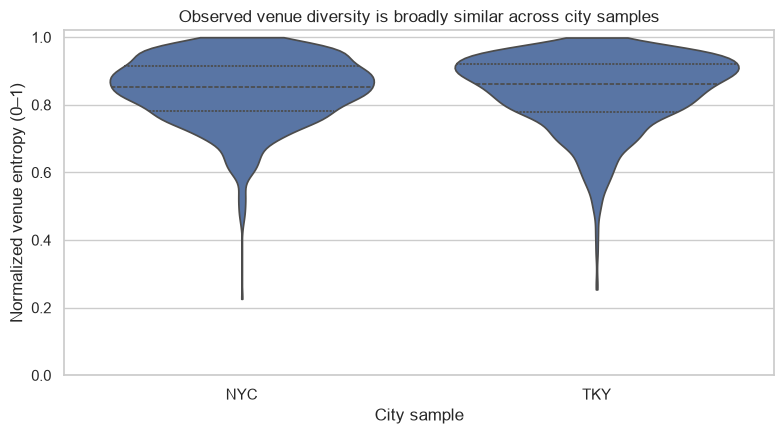

In [5]:
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.violinplot(data=metrics, x="city", y="normalized_entropy_venue", inner="quart", cut=0, ax=ax)
ax.set(title="Observed venue diversity is broadly similar across city samples",
       xlabel="City sample", ylabel="Normalized venue entropy (0–1)", ylim=(0, 1.02))
plt.tight_layout()
plt.show()

### Activity and observed repertoire

**Question.** Could entropy differences simply track how much is observed? Normalization controls the theoretical maximum for $K$, but it cannot erase the observation process.

**Evidence.** Rank correlations are descriptive. Normalized entropy has a moderate negative association with check-in count and a positive association with unique venues. This is a reminder to report all three measures rather than using entropy alone. Rank correlation is preferred to an unqualified linear fit because these count relationships are skewed and not assumed linear.

**Figure 2 — activity and unique venues versus normalized entropy.** Hexagonal bins reduce overplotting and expose density; each point underlying a bin is a non-spatial user summary with no identifier displayed.

In [6]:
rank_correlations = []
for city, group in metrics.groupby("city"):
    rank_correlations.append({
        "city": city,
        "Spearman-like rank corr: check-ins vs normalized entropy":
            group["observation_count_venue"].rank().corr(group["normalized_entropy_venue"].rank()),
        "Spearman-like rank corr: unique venues vs normalized entropy":
            group["unique_location_count_venue"].rank().corr(group["normalized_entropy_venue"].rank()),
    })
pd.DataFrame(rank_correlations).set_index("city").round(3)

,Spearman-like rank corr: check-ins vs normalized entropy,Spearman-like rank corr: unique venues vs normalized entropy
city,,
NYC,-0.296,0.499
TKY,-0.408,0.343


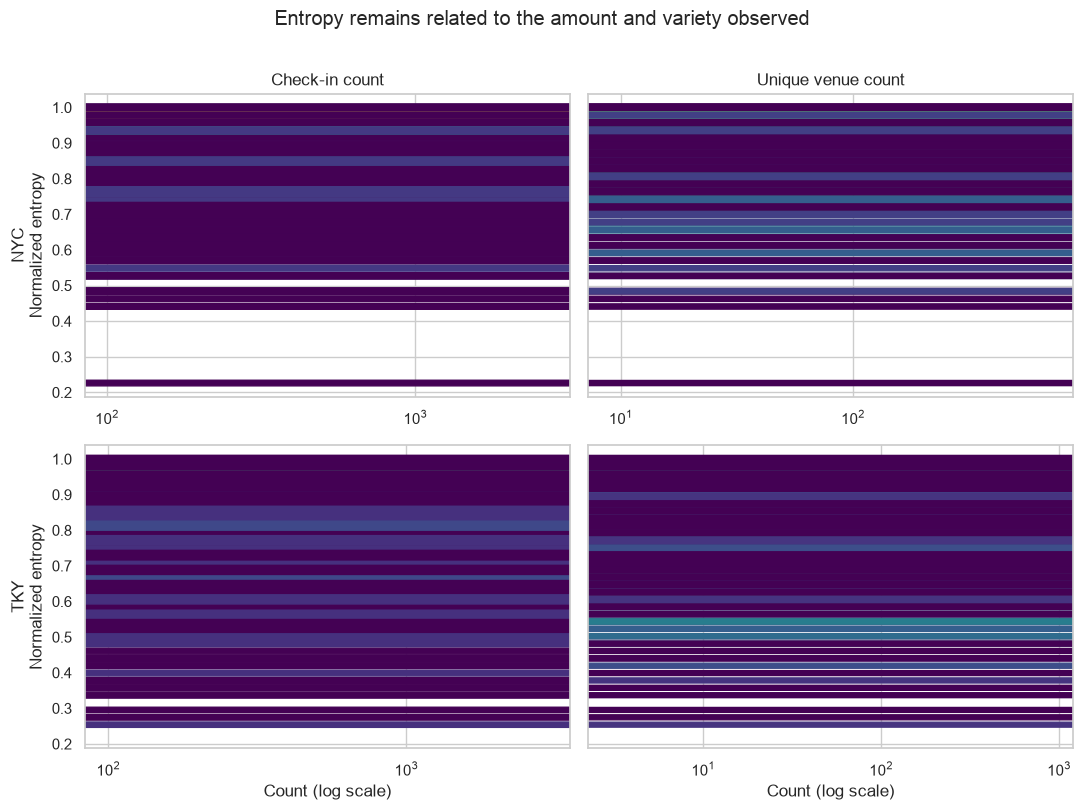

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharey=True)
for row, city in enumerate(CITY_ORDER):
    subset = metrics[metrics["city"] == city]
    axes[row, 0].hexbin(subset["observation_count_venue"], subset["normalized_entropy_venue"],
                        gridsize=32, mincnt=1, bins="log", cmap="viridis")
    axes[row, 1].hexbin(subset["unique_location_count_venue"], subset["normalized_entropy_venue"],
                        gridsize=32, mincnt=1, bins="log", cmap="viridis")
    axes[row, 0].set_ylabel(f"{city}\nNormalized entropy")
    axes[row, 0].set_xscale("log")
    axes[row, 1].set_xscale("log")
axes[0, 0].set_title("Check-in count")
axes[0, 1].set_title("Unique venue count")
for ax in axes[-1]: ax.set_xlabel("Count (log scale)")
fig.suptitle("Entropy remains related to the amount and variety observed", y=1.01)
plt.tight_layout()
plt.show()

## 5. Weekday versus weekend (P1)

**Question.** Is a user's observed venue pattern more diverse on weekends? Local calendar context is derived from authoritative city time zones. Entropy is recalculated independently, not by partitioning a previously calculated score.

**Decision.** Compare only users with at least **20 deduplicated check-ins in each context**. This pre-specified threshold avoids interpreting highly unstable context estimates; excluded counts are reported. The paired quantity is $\Delta H_{norm}=H_{weekend}-H_{weekday}$.

**Alternative rejected.** Pooling users or relying on p-values would obscure within-user effects and make tiny effects look important in a large observational sample. We use median, IQR, and an optional fixed-seed bootstrap interval for the median.

In [8]:
context_entropy = calculate_location_entropy(
    data, ["city", "user_id", "context"], "venue_id"
)
context_wide = context_entropy.pivot(
    index=["city", "user_id"], columns="context",
    values=["observation_count", "normalized_entropy"],
).fillna(0)
eligible_mask = (
    (context_wide[("observation_count", "weekday")] >= 20)
    & (context_wide[("observation_count", "weekend")] >= 20)
)
temporal = context_wide[eligible_mask].copy()
temporal["delta"] = (
    temporal[("normalized_entropy", "weekend")]
    - temporal[("normalized_entropy", "weekday")]
)

rows = []
for city in CITY_ORDER:
    delta = temporal.loc[city, "delta"]
    total = int((context_wide.reset_index()["city"] == city).sum())
    boot_medians = np.median(
        rng.choice(delta.to_numpy(), size=(10_000, len(delta)), replace=True), axis=1
    )
    rows.append({
        "city": city, "eligible_users": len(delta), "excluded_users": total - len(delta),
        "q25_delta": delta.quantile(.25), "median_delta": delta.median(),
        "q75_delta": delta.quantile(.75), "share_positive": (delta > 0).mean(),
        "bootstrap_95%_low": np.quantile(boot_medians, .025),
        "bootstrap_95%_high": np.quantile(boot_medians, .975),
    })
temporal_summary = pd.DataFrame(rows).set_index("city")
temporal_summary.round(3)

,eligible_users,excluded_users,q25_delta,median_delta,q75_delta,share_positive,bootstrap_95%_low,bootstrap_95%_high
city,,,,,,,,
NYC,1019,64,0.020,0.058,0.116,0.885,0.053,0.062
TKY,2142,151,0.016,0.059,0.131,0.854,0.055,0.063


**Result.** **1,019 NYC** users are eligible and **64 excluded**; **2,142 Tokyo** users are eligible and **151 excluded**. Median deltas are **+0.058 NYC** (IQR **0.020–0.116**, bootstrap 95% CI **0.053–0.062**) and **+0.059 Tokyo** (IQR **0.016–0.131**, CI **0.055–0.063**). The delta is positive for about **88.5%** and **85.4%** of eligible NYC and Tokyo users, respectively.

**Interpretation.** Eligible users generally show a broader/more even observed weekend venue repertoire. This is a reliable descriptive pattern in these data, not evidence that weekends *cause* exploration; different check-in propensities and activities may generate it.

**Figure 3 — paired weekend-minus-weekday distribution.**

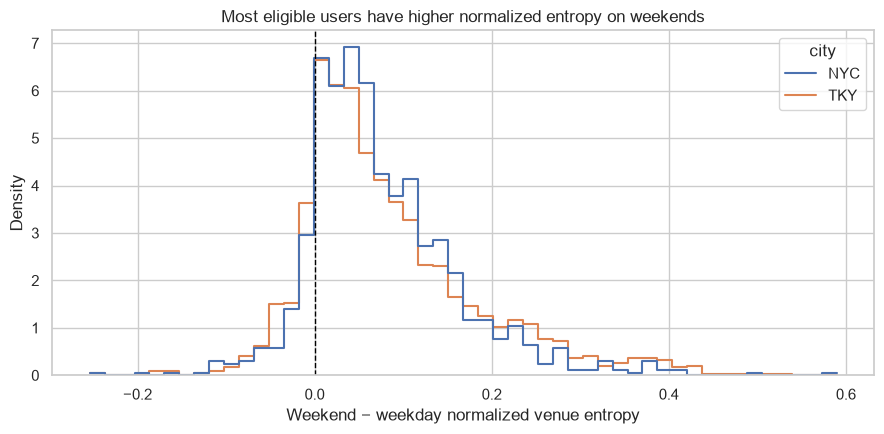

In [9]:
delta_plot = temporal["delta"].rename("delta").reset_index()
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.histplot(data=delta_plot, x="delta", hue="city", bins=50, stat="density",
             common_norm=False, element="step", fill=False, ax=ax)
ax.axvline(0, color="black", linewidth=1, linestyle="--")
ax.set(title="Most eligible users have higher normalized entropy on weekends",
       xlabel="Weekend − weekday normalized venue entropy", ylabel="Density")
plt.tight_layout()
plt.show()

## 6. Venue versus category diversity (P1)

**Question.** Does visiting many venues also imply semantically diverse activity? Category entropy repeats the same calculation using each event's recorded `category_id`; conflicting venue metadata is reported rather than canonicalized. Using display names instead was rejected because the specified semantic location is `category_id`; the report separately exposes the ID/name mismatch.

**Result.** Median normalized category entropy is **0.810 NYC** and **0.707 Tokyo**. Rank association between venue and category entropy is **0.897 NYC** and **0.728 Tokyo**. Venue diversity and semantic diversity are related but not interchangeable; Tokyo's high venue diversity often occurs within a more concentrated category repertoire.

**Figure 4 — venue/category relationship.**

In [10]:
category_summary = metrics.groupby("city").agg(
    median_normalized_venue_entropy=("normalized_entropy_venue", "median"),
    median_normalized_category_entropy=("normalized_entropy_category", "median"),
).round(3)
category_summary["rank_correlation"] = metrics.groupby("city").apply(
    lambda g: g["normalized_entropy_venue"].rank().corr(g["normalized_entropy_category"].rank()),
    include_groups=False,
).round(3)
category_summary

,median_normalized_venue_entropy,median_normalized_category_entropy,rank_correlation
city,,,
NYC,0.853,0.810,0.897
TKY,0.860,0.707,0.728


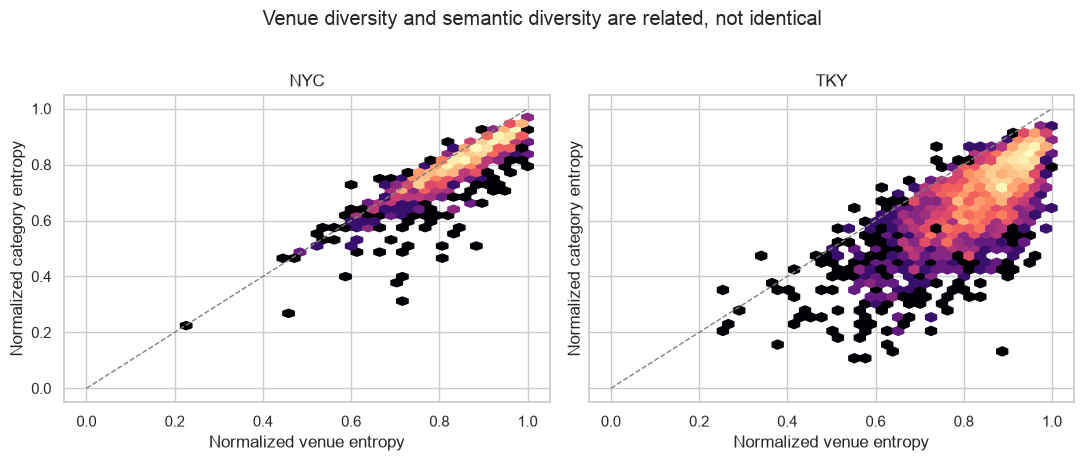

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharex=True, sharey=True)
for ax, city in zip(axes, CITY_ORDER):
    subset = metrics[metrics["city"] == city]
    ax.hexbin(subset["normalized_entropy_venue"], subset["normalized_entropy_category"],
              gridsize=30, mincnt=1, bins="log", cmap="magma")
    ax.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1)
    ax.set(title=city, xlabel="Normalized venue entropy", ylabel="Normalized category entropy")
fig.suptitle("Venue diversity and semantic diversity are related, not identical", y=1.02)
plt.tight_layout()
plt.show()

## 7. Relative behavioral cohorts and category composition (P1/P2)

**Decision.** Within each city, the bottom quartile is labeled `routine-oriented`, the middle half `mixed`, and top quartile `exploration-oriented`. These are relative descriptions of observed check-ins—not personality classifications. Quartiles are city-specific so the comparison concerns composition within a sample, not absolute cross-city rankings. Pooled global cutoffs were rejected because they would confound within-city behavior with sample/taxonomy differences.

**Evidence.** NYC's routine-oriented cohort has a larger `Home (private)` and office share, while its exploration-oriented cohort has a larger bar/restaurant/park mix. Tokyo's routine-oriented cohort is especially concentrated in train/subway check-ins; train stations remain common but have a much smaller share for exploration-oriented users. This composition explains why a single entropy score should not directly determine recommendations.

**Figure 5 — top category composition in low/high cohorts.** The displayed categories are selected by combined share within each city; all calculations use the full category set.

In [12]:
metrics["q25"] = metrics.groupby("city")["normalized_entropy_venue"].transform("quantile", q=.25)
metrics["q75"] = metrics.groupby("city")["normalized_entropy_venue"].transform("quantile", q=.75)
metrics["cohort"] = np.select(
    [metrics["normalized_entropy_venue"] <= metrics["q25"],
     metrics["normalized_entropy_venue"] >= metrics["q75"]],
    ["routine-oriented", "exploration-oriented"], default="mixed",
)
cohort_counts = metrics.groupby(["city", "cohort"]).size().rename("users").to_frame()
cohort_counts

users
city cohort                     
NYC  exploration-oriented    271
     mixed                   541
     routine-oriented        271
TKY  exploration-oriented    574
     mixed                  1145
     routine-oriented        574

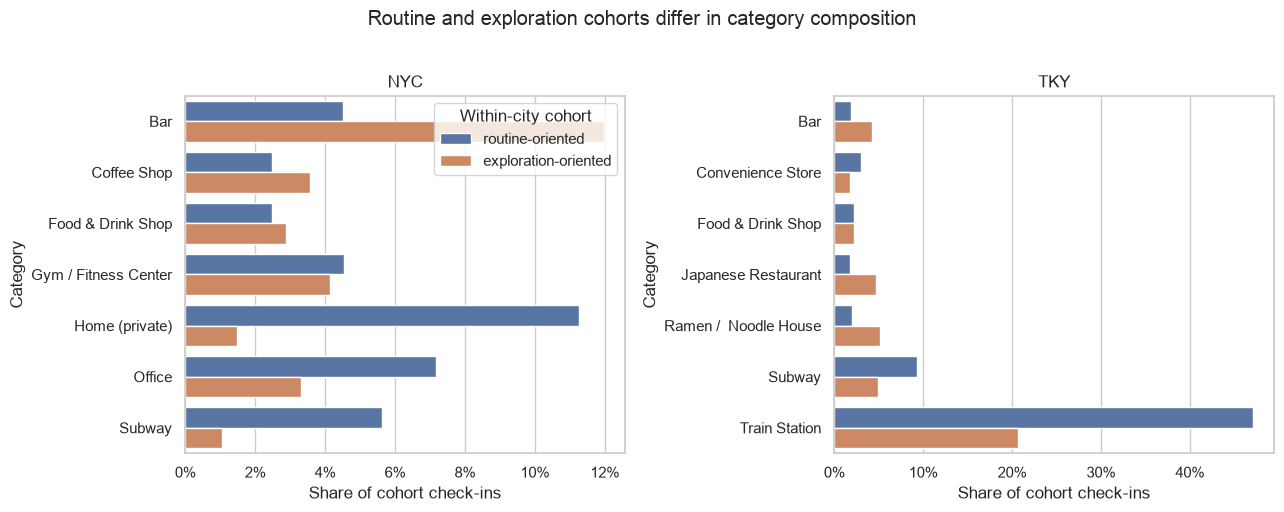

In [13]:
tagged = data.merge(metrics[["city", "user_id", "cohort"]], on=["city", "user_id"], validate="many_to_one")
composition = (
    tagged[tagged["cohort"] != "mixed"]
    .groupby(["city", "cohort", "category_name"], observed=True)
    .size().rename("checkins").reset_index()
)
composition["share"] = composition["checkins"] / composition.groupby(["city", "cohort"])["checkins"].transform("sum")

top_parts = []
for city in CITY_ORDER:
    city_comp = composition[composition["city"] == city]
    top_categories = (
        city_comp.groupby("category_name")["share"].sum().nlargest(7).index
    )
    top_parts.append(city_comp[city_comp["category_name"].isin(top_categories)])
top_composition = pd.concat(top_parts)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=False)
for ax, city in zip(axes, CITY_ORDER):
    subset = top_composition[top_composition["city"] == city]
    sns.barplot(data=subset, y="category_name", x="share", hue="cohort",
                hue_order=["routine-oriented", "exploration-oriented"], ax=ax)
    ax.set(title=city, xlabel="Share of cohort check-ins", ylabel="Category")
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
axes[1].legend_.remove()
axes[0].legend(title="Within-city cohort")
fig.suptitle("Routine and exploration cohorts differ in category composition", y=1.02)
plt.tight_layout()
plt.show()

## 8. Sensitivity: exclude `Home (private)` (P2)

**Question.** Does including private-home check-ins drive the headline result? Recalculate venue entropy after exclusion; this is a sensitivity check, not the primary metric, because home records are genuine routine signals. Exclusion was rejected as the primary definition; exposing home coordinates or trajectories is prohibited entirely.

**Result.** NYC median normalized entropy rises from **0.853 to 0.866**; Tokyo changes from **0.860 to 0.862**. The median *user-level* change is zero in both cities because most users have no private-home event. Inclusion matters more for NYC's aggregate distribution but does not reverse the broad two-city conclusion.

In [14]:
without_home = calculate_location_entropy(
    data[data["category_name"] != "Home (private)"], ["city", "user_id"], "venue_id"
).rename(columns={"normalized_entropy": "normalized_entropy_without_home"})
sensitivity = venue_entropy.merge(
    without_home[["city", "user_id", "normalized_entropy_without_home"]],
    on=["city", "user_id"], validate="one_to_one",
)
sensitivity["user_change"] = (
    sensitivity["normalized_entropy_without_home"] - sensitivity["normalized_entropy"]
)
sensitivity.groupby("city").agg(
    median_with_home=("normalized_entropy", "median"),
    median_without_home=("normalized_entropy_without_home", "median"),
    median_user_change=("user_change", "median"),
).round(3)

,median_with_home,median_without_home,median_user_change
city,,,
NYC,0.853,0.866,0.0
TKY,0.860,0.862,0.0


## 9. Evidence-led product proposal

### Context-aware venue discovery

**Observed finding** → normalized venue entropy has a wide within-city range; semantic diversity differs from venue diversity; eligible users usually show higher weekend diversity, but not all do.

**User problem** → a fixed novelty level can make recommendations feel repetitive to users whose observed repertoire is broad, while overwhelming users whose behavior is concentrated. A city-level stereotype would miss substantial individual variation.

**Proposed feature** → adjust recommendation novelty using a *versioned, confidence-gated* combination of normalized venue and category entropy. Offer nearer/familiar alternatives for routine-oriented behavior and broader discovery for exploration-oriented behavior. Apply a weekday/weekend adjustment only after adequate context history and a stable personal delta; otherwise fall back to a context-neutral policy. Entropy is one ranking feature, never a personality label.

**Experiment** → within users eligible for personalization, randomize current ranking versus entropy-aware novelty. Stratify randomization by city, activity band, baseline venue/category entropy, and context; pre-register a minimum detectable effect and run long enough to cover weekdays and weekends.

**Primary KPI** → recommendation save rate (or another explicit positive-intent action) per recommendation impression.

**Guardrails** → hide/dismiss rate, short-session abandonment, repeat exposure, category/provider coverage, geographic distance, latency, and performance by activity/entropy strata. Monitor whether the policy reduces utility for sparse-history users.

**Privacy/data risks** → minimize retention, avoid inferred home/work, never expose entropy labels, do not use private-home coordinates, aggregate monitoring, set history expiry, provide controls, and audit proxy discrimination. Voluntary check-ins are not complete mobility traces.

**Brief extensions (not implemented).** (1) opt-in neighborhood discovery using coarse, privacy-reviewed aggregates; (2) aggregate merchant audience mix without individual profiles; (3) user-facing predictability/privacy warnings computed on-device where feasible.

## 10. Limitations, production path, and conclusion

### Required interpretive limits

- Check-ins are voluntary and subject to selection and reporting bias.
- Check-ins do not equal dwell time, purchases, demand, or footfall.
- Entropy depends on observation count and the observation process; normalization does not remove sampling bias.
- This 2012–2013 historical dataset cannot establish current product behavior.
- NYC and Tokyo samples are not representative of their full populations.
- Cross-city differences must not be interpreted as causal or cultural effects.
- All findings are observational and do not establish causation.
- Venue/category conflicts, category-taxonomy differences, and duplicate removal add measurement uncertainty. A 20-event threshold improves stability but is not a proof of reliability.

### Production foundations and likely scaling path

The submission has an explicit schema and validation, composite identities, reusable metric API, separated loading/calculation/reporting, deterministic analysis, unit tests, and clear errors. At larger scale, validated events could be stored as partitioned Parquet; vectorized aggregation could move to Polars or Spark. A scheduled pipeline should monitor schema drift, nulls, duplicates, timezone anomalies, venue-metadata conflicts, and metric distributions. Metric definitions, cohort thresholds, and context eligibility rules should be versioned. This is a scaling discussion—not a claim that the notebook is a real-time pipeline or has hardware-independent runtime.

### Answer

Observed venue patterns are diverse for the typical user in both samples, with very similar median normalized venue entropy. Diversity varies much more within each city than the city medians differ. Weekend check-ins are more diverse for most context-eligible users, and category entropy shows that venue variety can occur within a narrower semantic repertoire. Product use should therefore be personal, context-aware, confidence-gated, and privacy-preserving—not city-stereotyped.

### Dataset citation

Yang, D., Zhang, D., Zheng, V. W., & Yu, Z. (2015). Modeling User Activity Preference by Leveraging User Spatial Temporal Characteristics in LBSNs. *IEEE Transactions on Systems, Man, and Cybernetics: Systems*, 45(1), 129–142.